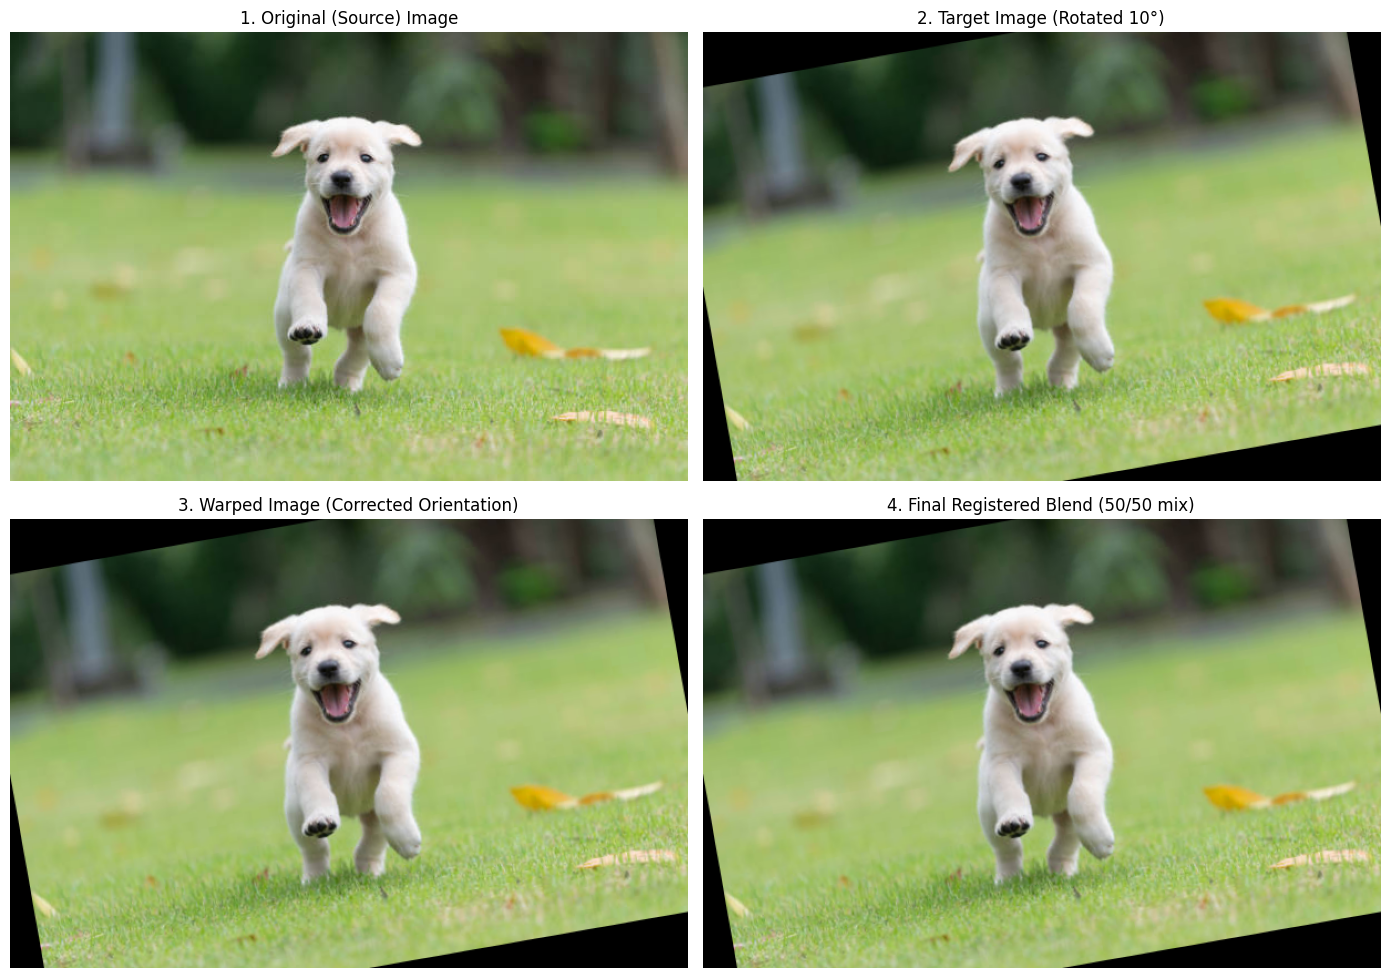

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_SIFT(img):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)
    return kp, des

def match_SIFT(descriptor_source, descriptor_target):
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(descriptor_source, descriptor_target, k=2)
    
    pos = np.empty((0, 2), dtype=int)
    
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            temp = np.array([m.queryIdx, m.trainIdx])
            pos = np.vstack((pos, temp))
    return pos

def affine_matrix(keypoint_source, keypoint_target, pos):
    src_pts = np.float32([keypoint_source[idx].pt for idx in pos[:, 0]]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoint_target[idx].pt for idx in pos[:, 1]]).reshape(-1, 1, 2)
    
    M, inliers = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    
    if M is None:
        return np.hstack((np.eye(2), np.zeros((2, 1))))
        
    return M

path_source = "IMAGE-1.jpg"
img_source = cv2.imread(path_source)

if img_source is None:
    raise FileNotFoundError(f"Error: Could not load {path_source}.")

rows, cols, _ = img_source.shape

rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), 10, 1.0)
img_target = cv2.warpAffine(img_source, rotation_matrix, (cols, rows))

keypoint_source, descriptor_source = extract_SIFT(img_source)
keypoint_target, descriptor_target = extract_SIFT(img_target)

pos = match_SIFT(descriptor_source, descriptor_target)

if len(pos) < 3:
    raise ValueError("Not enough matching points found to compute the registration.")

H = affine_matrix(keypoint_source, keypoint_target, pos)

warp = cv2.warpAffine(img_source, H, (cols, rows))

merge = np.uint8(img_target * 0.5 + warp * 0.5)

img_source_rgb = cv2.cvtColor(img_source, cv2.COLOR_BGR2RGB)
img_target_rgb = cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB)
warp_rgb = cv2.cvtColor(warp, cv2.COLOR_BGR2RGB)
merge_rgb = cv2.cvtColor(merge, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_source_rgb)
axes[0, 0].set_title("1. Original (Source) Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_target_rgb)
axes[0, 1].set_title("2. Target Image (Rotated 10°)")
axes[0, 1].axis('off')

axes[1, 0].imshow(warp_rgb)
axes[1, 0].set_title("3. Warped Image (Corrected Orientation)")
axes[1, 0].axis('off')

axes[1, 1].imshow(merge_rgb)
axes[1, 1].set_title("4. Final Registered Blend (50/50 mix)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()